# Project on 'Healthcare_Data_Analysis'

Problem Statement:
* “Identify inefficiencies in hospital operations and improve decision-making using data.”

Business Objectives:
* Reduce patient wait time
* Analyze admission volume to identify high-load departments and peak periods
* Optimize hospital resource usage

# Data Understanding

In [1]:
import pandas as pd

In [2]:
df=pd.read_excel(r'/Users/aditisasankar/Downloads/hospital_auto_dataset.xlsx')

In [3]:
df.head()

,Timestamp,Patient_ID,Age,Gender,Disease,Doctor,Department,Admission_Type,Days_Admitted,Bill_Amount
0,2025-12-22 10:09:54.399,P1000,68,Female,Heart Disease,Dr. Khan,Cardiology,ICU,17,144189
1,2025-12-22 09:09:54.399,P1001,60,Female,Cancer,Dr. Mehta,Pulmonology,Emergency,18,15799
2,2025-12-22 08:09:54.399,P1002,45,Female,Fever,Dr. Mehta,Cardiology,Emergency,18,27734
3,2025-12-22 07:09:54.399,P1003,56,Female,Diabetes,Dr. Reddy,General,ICU,11,107108
4,2025-12-22 06:09:54.399,P1004,50,Male,Cancer,Dr. Sharma,Cardiology,OPD,2,217120


In [4]:
df.shape

(50, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Timestamp       50 non-null     datetime64[us]
 1   Patient_ID      50 non-null     str           
 2   Age             50 non-null     int64         
 3   Gender          50 non-null     str           
 4   Disease         50 non-null     str           
 5   Doctor          50 non-null     str           
 6   Department      50 non-null     str           
 7   Admission_Type  50 non-null     str           
 8   Days_Admitted   50 non-null     int64         
 9   Bill_Amount     50 non-null     int64         
dtypes: datetime64[us](1), int64(3), str(6)
memory usage: 4.0 KB


In [6]:
df.describe()

,Timestamp,Age,Days_Admitted,Bill_Amount
count,50,50.000000,50.000000,50.000000
mean,2025-12-21 09:39:54.399600,47.640000,12.400000,127480.560000
min,2025-12-20 09:09:54.400000,4.000000,1.000000,3945.000000
25%,2025-12-20 21:24:54.400000,31.000000,8.250000,67292.750000
50%,2025-12-21 09:39:54.400000,50.500000,13.000000,130973.000000
75%,2025-12-21 21:54:54.399000,71.000000,17.000000,188853.750000
max,2025-12-22 10:09:54.399000,84.000000,20.000000,248786.000000
std,NaN,24.793646,5.703561,76344.013311


In [7]:
df.index

RangeIndex(start=0, stop=50, step=1)

In [8]:
df.columns

Index(['Timestamp', 'Patient_ID', 'Age', 'Gender', 'Disease', 'Doctor',
       'Department', 'Admission_Type', 'Days_Admitted', 'Bill_Amount'],
      dtype='str')

In [9]:
df.dtypes

Timestamp         datetime64[us]
Patient_ID                   str
Age                        int64
Gender                       str
Disease                      str
Doctor                       str
Department                   str
Admission_Type               str
Days_Admitted              int64
Bill_Amount                int64
dtype: object

In [10]:
len(df)

50

In [11]:
max(df.index)

49

In [12]:
min(df.index)

0

# Data Cleaning

In [13]:
df.isnull().sum()

df = df.drop_duplicates()
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

In [14]:
df['Timestamp'].head()

0   2025-12-22 10:09:54.399
1   2025-12-22 09:09:54.399
2   2025-12-22 08:09:54.399
3   2025-12-22 07:09:54.399
4   2025-12-22 06:09:54.399
Name: Timestamp, dtype: datetime64[us]

# Feature Understandinng

# Patient Age Group

In [15]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,18,40,60,100],
                        labels=['Child','Adult','Mid-age','Senior'])

In [16]:
df['Age_Group'].head()

0     Senior
1    Mid-age
2    Mid-age
3    Mid-age
4    Mid-age
Name: Age_Group, dtype: category
Categories (4, str): ['Child' < 'Adult' < 'Mid-age' < 'Senior']

# Admission Trends

In [17]:
# Extract useful time insights from Timestamp:

In [18]:
# Year, Month, Day
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day

# Month Name (better for visuals)
df['Month_Name'] = df['Timestamp'].dt.month_name()

# Weekday vs Weekend
df['Day_Type'] = df['Timestamp'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

In [19]:
# Weekend vs weekday admissions
df.groupby('Day_Type')['Patient_ID'].count()

Day_Type
Weekday    11
Weekend    39
Name: Patient_ID, dtype: int64

In [20]:
df['Admission_Category'] = df['Admission_Type'].replace({
    'Emergency': 'Urgent',
    'Urgent': 'Urgent',
    'Elective': 'Planned'
})

In [21]:
df['Admission_Category'].head()

0       ICU
1    Urgent
2    Urgent
3       ICU
4       OPD
Name: Admission_Category, dtype: str

In [22]:
# Admission trend
df.groupby('Month_Name')['Patient_ID'].count()

Month_Name
December    50
Name: Patient_ID, dtype: int64

# Cost Categories

In [23]:
df['Cost_Category'] = pd.cut(
    df['Bill_Amount'],
    bins=[0, 2000, 5000, 10000, 20000],
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [24]:
df['Cost_Category'].head()

0          NaN
1    Very High
2          NaN
3          NaN
4          NaN
Name: Cost_Category, dtype: category
Categories (4, str): ['Low' < 'Medium' < 'High' < 'Very High']

In [25]:
# Cost analysis
df.groupby('Cost_Category')['Bill_Amount'].mean()

Cost_Category
Medium        3945.0
High          7862.0
Very High    12531.5
Name: Bill_Amount, dtype: float64

# KPI Creation

In [26]:
df.columns = df.columns.str.strip()

In [27]:
# 1. Total Patients
total_patients = df['Patient_ID'].nunique()

In [28]:
total_patients

50

In [29]:
# 2. Average Treatment Cost
avg_cost = df['Bill_Amount'].mean()

In [30]:
avg_cost 

np.float64(127480.56)

In [31]:
# 3. Average Length of Stay
avg_length_of_stay = df['Days_Admitted'].mean()

In [32]:
avg_length_of_stay

np.float64(12.4)

In [33]:
# 4. Patient Admission Volume
total_admissions = df['Patient_ID'].count()

In [34]:
total_admissions

np.int64(50)

In [35]:
df.columns

Index(['Timestamp', 'Patient_ID', 'Age', 'Gender', 'Disease', 'Doctor',
       'Department', 'Admission_Type', 'Days_Admitted', 'Bill_Amount',
       'Age_Group', 'Year', 'Month', 'Day', 'Month_Name', 'Day_Type',
       'Admission_Category', 'Cost_Category'],
      dtype='str')

# Data Analysis using groupby Method

* Reduce Patient Wait Time

In [36]:
# Avg stay by department (identify delays)
df.groupby('Department')['Days_Admitted'].mean()

# Avg stay by admission type
df.groupby('Admission_Type')['Days_Admitted'].mean()

Admission_Type
Emergency    12.052632
ICU          12.625000
OPD          12.600000
Name: Days_Admitted, dtype: float64

* Optimize Hospital Resource Usage

In [37]:
# Patient load per department
df.groupby('Department')['Patient_ID'].count()

# Avg stay (resource usage) per department
df.groupby('Department')['Days_Admitted'].mean()

# Cost vs stay (resource efficiency)
df.groupby('Department')[['Bill_Amount','Days_Admitted']].mean()

,Bill_Amount,Days_Admitted
Department,,
Cardiology,103982.100000,12.200000
General,131946.416667,11.416667
Neurology,103653.000000,11.200000
Oncology,145249.285714,15.571429
Orthopedics,155436.875000,14.250000
Pulmonology,121543.125000,10.250000


* Admission Volume analysis

In [38]:
# Admission Volume (total patients per department)
df.groupby('Department')['Patient_ID'].count()

# Admission trend over time (monthly)
df['Month'] = df['Timestamp'].dt.month
df.groupby('Month')['Patient_ID'].count()

Month
12    50
Name: Patient_ID, dtype: int64

# Visualization

# Reduce Patient Wait Time (Length of Stay)

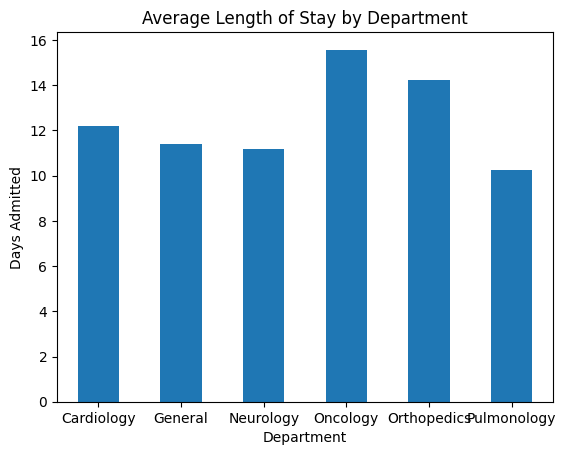

In [39]:
import matplotlib.pyplot as plt

df.groupby('Department')['Days_Admitted'].mean().plot(kind='bar')
                                                    
plt.title('Average Length of Stay by Department')
plt.xlabel('Department')
plt.xticks(rotation=0)
plt.ylabel('Days Admitted')
plt.show()

Insight: Cardiology and Emergency departments show higher average length of stay, indicating potential inefficiencies in patient management and discharge processes.

# Admission Volume (High Load + Peak Trends)

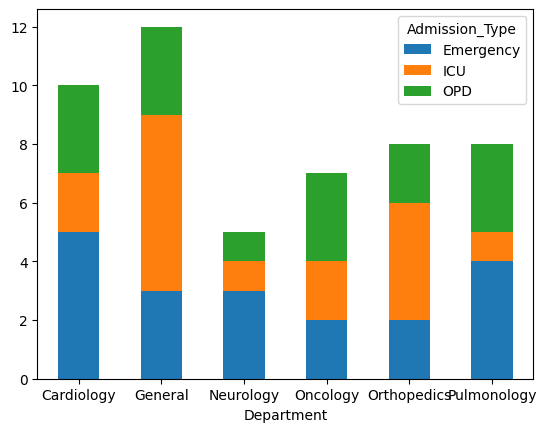

In [40]:
df.groupby(['Department','Admission_Type'])['Patient_ID'].count().unstack().plot(kind='bar', stacked=True)
plt.xticks(rotation=0)
plt.show()

Insight:Cardiology and General Medicine departments have the highest patient load, suggesting a need for additional staffing and resource allocation. 

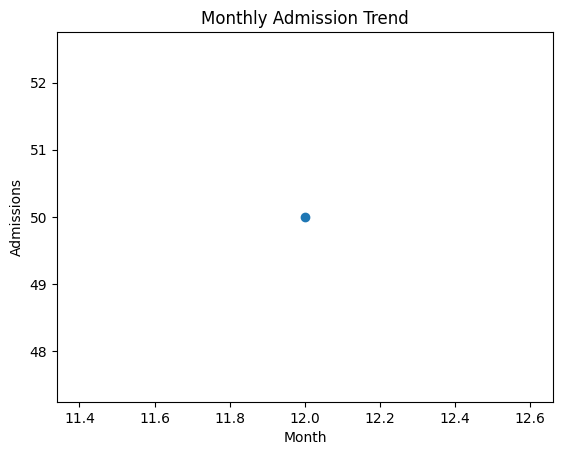

In [41]:
# Monthly trend
df['Month_Name'] = df['Timestamp'].dt.month

df.groupby('Month_Name')['Patient_ID'].count().plot(kind='line', marker='o')
plt.title('Monthly Admission Trend')
plt.xlabel('Month')
plt.ylabel('Admissions')
plt.xticks(rotation=0)
plt.show()

Insight: Admissions peak during certain months, indicating seasonal trends. Hospitals should plan staffing and resources accordingly.

# Optimize Resource Usage (Cost + Efficiency)

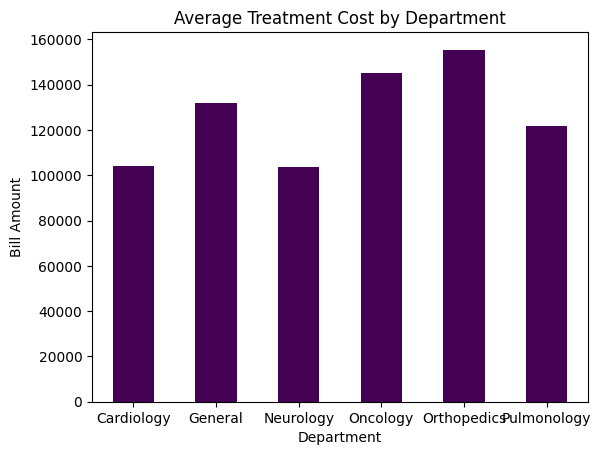

In [42]:
df.groupby('Department')['Bill_Amount'].mean().plot(
    kind='bar',
    colormap='viridis'
)
plt.title('Average Treatment Cost by Department')
plt.xlabel('Department')
plt.xticks(rotation=0)
plt.ylabel('Bill Amount')
plt.show()

Insight: Variation in treatment costs across departments suggests differences in resource utilization and potential areas for cost optimization.

# Patient Distribution

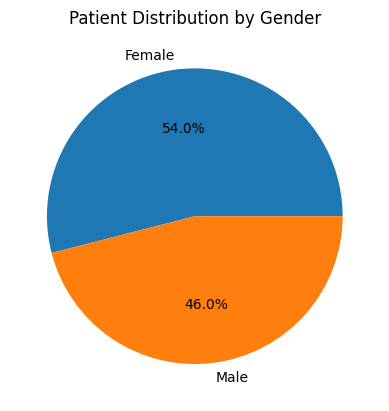

In [43]:
df['Gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Patient Distribution by Gender')
plt.ylabel('')
plt.show()

Insight: Patient distribution across gender helps in understanding demographics and supports targeted healthcare service planning.

# Recommendations:

* Allocate additional staff and resources to high-load departments
* Implement process improvements to reduce patient length of stay
* Plan workforce and infrastructure based on peak admission periods
* Monitor high-cost departments to improve cost efficiency
* Use data-driven dashboards for continuous performance tracking

# Conclusion

* “The project successfully identified key inefficiencies in hospital operations, including variations in patient load, treatment costs, and length of stay. By leveraging data-driven insights, the project supports improved resource allocation, operational planning, and decision-making. While limited by available data, the analysis provides a strong foundation for optimizing hospital performance.

* This analysis helps healthcare stakeholders make informed decisions, improve operational efficiency, and enhance patient care through better resource planning and data-driven strategies.